In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [6]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [7]:
import cv2
# Read the image as a NumPy array
img = cv2.imread("image.jpeg")


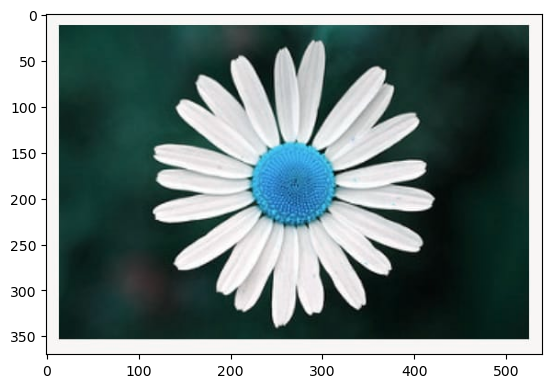

In [8]:
# Display the image
plt.imshow(img)
plt.axis('on') # Hide coordinate axes
plt.show()


In [9]:
# 1. Load the image and convert BGR (OpenCV default) to RGB
#image = cv2.imread("image.jpeg")
image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Flatten the image into a 2D array of RGB pixels
pixels = image.reshape((-1, 3))
pixels = np.float32(pixels)  # Convert to float for K-Means accuracy


In [10]:
# 2. Calculate WCSS for the Elbow Method
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(pixels)
    wcss.append(kmeans.inertia_)  # inertia_ holds the WCSS value
    

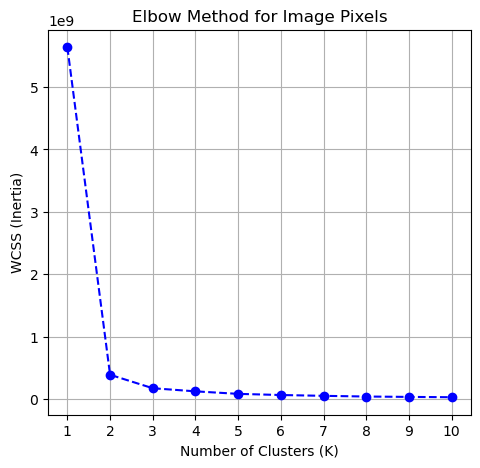

In [11]:
# 3. Plot the WCSS Graph
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Image Pixels')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)


In [20]:
# 4. Generate Segmentation with Optimal K (e.g., K=3 based on your elbow plot)
optimal_k = 20 
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
labels = kmeans_final.fit_predict(pixels)

# Replace pixel values with their respective cluster center colors
centers = np.uint8(kmeans_final.cluster_centers_)
segmented_pixels = centers[labels.flatten()]
segmented_image = segmented_pixels.reshape(image.shape)


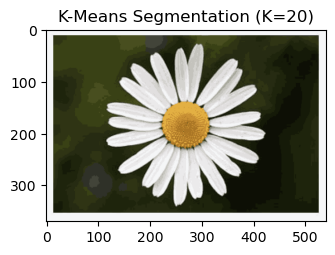

In [21]:
# 5. Plot the Segmented Image side-by-side
plt.subplot(1, 2, 2)
plt.imshow(segmented_image)
plt.title(f'K-Means Segmentation (K={optimal_k})')
plt.axis('on')

plt.tight_layout()
plt.show()
